<a href="https://colab.research.google.com/github/theiceman07/Blockchain-Visualizer/blob/main/Blockchain_Visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 0 — Setup

In [ ]:
!pip -q install ipywidgets networkx

# Colab: enable widgets in the output area
from google.colab import output
output.enable_custom_widget_manager()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.2 MB/s eta 0:00:00


Cell 1 — Imports & helpers

In [ ]:
import time, json, hashlib, textwrap, math
from dataclasses import dataclass, asdict, field
from typing import List, Dict, Any, Optional

import ipywidgets as w
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import networkx as nx

def sha256(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def truncate(h: str, n: int = 10) -> str:
    return h[:n]


Cell 2 — Merkle root (simple) & Block model

In [ ]:
def merkle_root(items: List[str]) -> str:
    """Very small Merkle implementation (string leaves)."""
    if not items:
        return sha256("EMPTY")
    layer = [sha256(x) for x in items]
    while len(layer) > 1:
        # if odd, duplicate last
        if len(layer) % 2 == 1:
            layer.append(layer[-1])
        layer = [sha256(layer[i] + layer[i+1]) for i in range(0, len(layer), 2)]
    return layer[0]

@dataclass
class Block:
    index: int
    timestamp: float
    prev_hash: str
    nonce: int
    data: List[Dict[str, Any]] = field(default_factory=list)
    merkle: str = ""
    hash: str = ""

    def compute_hash(self) -> str:
        payload = json.dumps({
            "index": self.index,
            "timestamp": self.timestamp,
            "prev_hash": self.prev_hash,
            "nonce": self.nonce,
            "merkle": self.merkle,
            "data": self.data
        }, sort_keys=True)
        return sha256(payload)

    def mine(self, difficulty: int = 3):
        """Proof-of-Work: find hash with difficulty leading zeros."""
        target = "0" * difficulty
        self.merkle = merkle_root([json.dumps(tx, sort_keys=True) for tx in self.data])
        self.nonce = 0
        while True:
            self.hash = self.compute_hash()
            if self.hash.startswith(target):
                break
            self.nonce += 1

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


  Cell 3 — Blockchain core (genesis, add, validate)

In [ ]:
class Blockchain:
    def __init__(self, difficulty: int = 3, block_capacity: int = 5):
        self.difficulty = difficulty
        self.block_capacity = block_capacity
        self.chain: List[Block] = []
        self.mempool: List[Dict[str, Any]] = []
        self.create_genesis()

    def create_genesis(self):
        g = Block(index=0, timestamp=time.time(), prev_hash="GENESIS", nonce=0, data=[{"genesis": True}])
        g.mine(self.difficulty)
        self.chain = [g]

    def last_block(self) -> Block:
        return self.chain[-1]

    def add_tx(self, sender: str, receiver: str, amount: float, note: str = ""):
        self.mempool.append({
            "sender": sender, "receiver": receiver, "amount": float(amount), "note": note, "ts": time.time()
        })

    def mine_pending(self) -> Block:
        if not self.mempool:
            # empty block allowed (educational)
            batch = []
        else:
            batch = self.mempool[:self.block_capacity]
            self.mempool = self.mempool[self.block_capacity:]

        b = Block(
            index=len(self.chain),
            timestamp=time.time(),
            prev_hash=self.last_block().hash,
            nonce=0,
            data=batch
        )
        b.mine(self.difficulty)
        self.chain.append(b)
        return b

    def is_valid(self) -> (bool, Optional[int], str):
        """Returns (valid?, break_index, reason)."""
        target = "0" * self.difficulty
        for i in range(1, len(self.chain)):
            prev, cur = self.chain[i-1], self.chain[i]
            # prev_hash link
            if cur.prev_hash != prev.hash:
                return False, i, "Broken prev_hash link"
            # proof-of-work
            if not cur.hash.startswith(target):
                return False, i, "Hash does not satisfy difficulty"
            # merkle & hash integrity
            expected_merkle = merkle_root([json.dumps(tx, sort_keys=True) for tx in cur.data])
            if expected_merkle != cur.merkle:
                return False, i, "Merkle mismatch"
            if cur.compute_hash() != cur.hash:
                return False, i, "Block hash mismatch"
        return True, None, "OK"

    def to_json(self) -> str:
        return json.dumps([b.to_dict() for b in self.chain], indent=2)

    @staticmethod
    def from_json(s: str) -> "Blockchain":
        obj = Blockchain()
        obj.chain = []
        raw = json.loads(s)
        for b in raw:
            block = Block(**b)
            obj.chain.append(block)
        return obj


Cell 4 — Create a chain & quick smoke test

In [ ]:
bc = Blockchain(difficulty=3, block_capacity=4)
for i in range(6):
    bc.add_tx("Alice", "Bob", i+1, note=f"Payment {i+1}")
bc.mine_pending()
bc.mine_pending()

ok, idx, reason = bc.is_valid()
print("Valid?", ok, "|", reason)
print(f"Blocks: {len(bc.chain)}  Pending tx: {len(bc.mempool)}")
print("Head hash:", bc.last_block().hash)


Valid? True | OK
Blocks: 3  Pending tx: 0
Head hash: 00089323f3fa30ad6d703b79dee2fa506414c019003fb81b278126cf1652431e


Cell 5 — Visualize chain (NetworkX + Matplotlib)

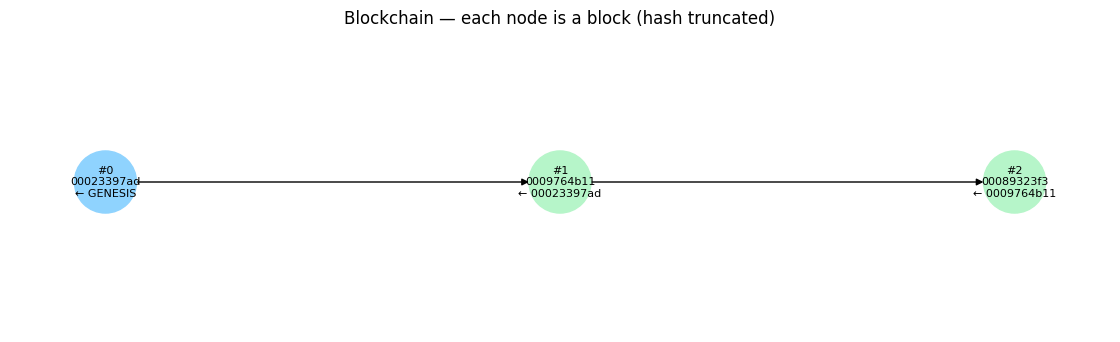

In [ ]:
def draw_chain(chain: Blockchain, figsize=(11, 3)):
    G = nx.DiGraph()
    labels = {}
    colors = []
    for b in chain.chain:
        label = f"#{b.index}\n{truncate(b.hash)}\n← {truncate(b.prev_hash)}"
        G.add_node(b.index)
        labels[b.index] = label
        colors.append("#8fd3fe" if b.index==0 else "#b6f5c9")
    for i in range(1, len(chain.chain)):
        G.add_edge(i-1, i)

    pos = {i: (i, 0) for i in range(len(chain.chain))}
    plt.figure(figsize=figsize)
    nx.draw(G, pos, with_labels=False, node_color=colors, node_size=2000, arrows=True)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title("Blockchain — each node is a block (hash truncated)")
    plt.axis("off")
    plt.show()

draw_chain(bc)


Cell 6 — Interactive controls (add tx, mine, validate, visualize)

In [ ]:
sender = w.Text(description="From:", placeholder="Alice")
receiver = w.Text(description="To:", placeholder="Bob")
amount = w.BoundedFloatText(description="Amount:", min=0, max=1e9, step=0.5, value=10.0)
note = w.Text(description="Note:", placeholder="Optional")
btn_add = w.Button(description="Add Tx", button_style="info")
btn_mine = w.Button(description="Mine Block", button_style="success")
btn_check = w.Button(description="Validate", button_style="")
out = w.Output()

def on_add(_):
    with out:
        if not sender.value or not receiver.value:
            print("Please enter sender & receiver.")
            return
        bc.add_tx(sender.value, receiver.value, amount.value, note.value)
        print(f"Added tx: {sender.value} → {receiver.value} : {amount.value}")
        print("Pending tx:", len(bc.mempool))

def on_mine(_):
    with out:
        if not bc.mempool:
            print("No pending transactions. Mining empty block (allowed).")
        b = bc.mine_pending()
        print(f"Mined block #{b.index} | hash startswith {'0'*bc.difficulty}? {b.hash.startswith('0'*bc.difficulty)}")
        draw_chain(bc)

def on_check(_):
    with out:
        ok, idx, reason = bc.is_valid()
        print("Chain valid?", ok, "|", reason, "| at index:", idx)

btn_add.on_click(on_add)
btn_mine.on_click(on_mine)
btn_check.on_click(on_check)

ui = w.VBox([
    w.HTML("<h3>Blockchain Visualizer — Controls</h3>"),
    w.HBox([sender, receiver]),
    w.HBox([amount, note]),
    w.HBox([btn_add, btn_mine, btn_check]),
    out
])
display(ui)


Cell 7 — Tamper demo (edit a past block and see validation fail)

Tampered block #1. Now validating…
Valid? False | Break at: 1 | Reason: Block hash mismatch


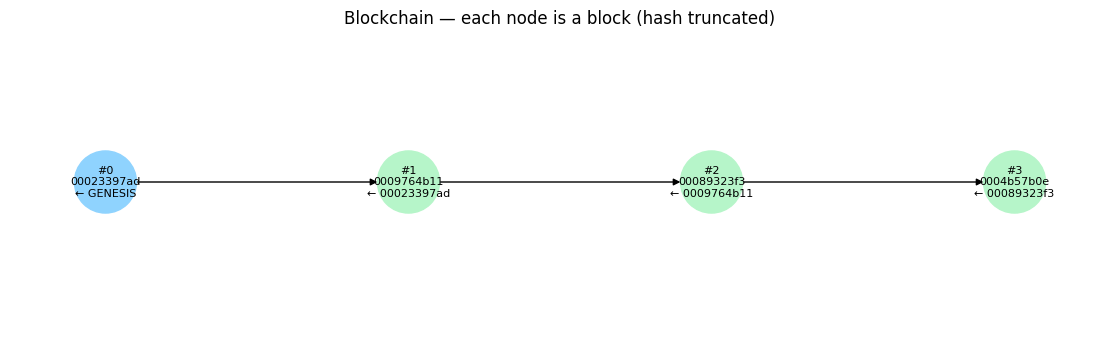

In [ ]:
def tamper_block(block_index: int, new_note: str = "TAMPERED"):
    if block_index <= 0 or block_index >= len(bc.chain):
        print("Choose a non-genesis block index within chain range.")
        return
    blk = bc.chain[block_index]
    # Tamper: change the first tx note (or add a fake one if none)
    if blk.data:
        blk.data[0]["note"] = new_note
    else:
        blk.data.append({"sender": "X", "receiver": "Y", "amount": 999, "note": new_note, "ts": time.time()})
    # Recompute merkle but DO NOT re-mine — simulating malicious edit
    blk.merkle = merkle_root([json.dumps(tx, sort_keys=True) for tx in blk.data])
    # Hash remains outdated, so validation should fail
    print(f"Tampered block #{block_index}. Now validating…")
    ok, idx, reason = bc.is_valid()
    print("Valid?", ok, "| Break at:", idx, "| Reason:", reason)

# Example: tamper block #1 (if exists)
if len(bc.chain) > 1:
    tamper_block(1, "Changed after mining!")
    draw_chain(bc)


Cell 8 — Save / Load the chain (download & restore)

In [ ]:
from google.colab import files

def save_chain(filename="blockchain.json"):
    s = bc.to_json()
    with open(filename, "w") as f:
        f.write(s)
    files.download(filename)

def load_chain_from_file():
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    with open(fname, "r") as f:
        s = f.read()
    global bc
    bc = Blockchain.from_json(s)
    print("Loaded chain with", len(bc.chain), "blocks.")
    draw_chain(bc)

# Usage:
# save_chain()
# load_chain_from_file()


Cell 9 — Adjust difficulty & capacity, then mine again

In [ ]:
bc.difficulty = 4          # more zeros → slower mining
bc.block_capacity = 3      # fewer tx per block
print("New settings => difficulty:", bc.difficulty, "| capacity:", bc.block_capacity)


New settings => difficulty: 4 | capacity: 3


A) Balances (toy ledger) + mining reward

In [ ]:
# --- Cell A: simple balances + reward ---
from collections import defaultdict

MINING_REWARD = 25.0  # toy reward

def compute_balances(chain) -> dict:
    bal = defaultdict(float)
    for b in chain.chain:
        for tx in b.data:
            if tx.get("coinbase"):     # mining reward tx
                bal[tx["receiver"]] += tx["amount"]
            else:
                s, r, a = tx["sender"], tx["receiver"], float(tx["amount"])
                bal[s] -= a
                bal[r] += a
    return dict(bal)

def can_afford(chain, sender, amount) -> bool:
    return compute_balances(chain).get(sender, 0.0) >= float(amount)

# Patch Blockchain to enforce affordability and add reward on mine:
def add_tx_checked(sender, receiver, amount, note=""):
    amount = float(amount)
    if sender != "COINBASE" and not can_afford(bc, sender, amount):
        raise ValueError(f"{sender} cannot afford {amount}. Balance: {compute_balances(bc).get(sender,0):.2f}")
    bc.add_tx(sender, receiver, amount, note)

def mine_with_reward(miner_address="miner1"):
    # coinbase (reward) goes first in batch
    bc.mempool.insert(0, {"sender":"COINBASE","receiver":miner_address,"amount":MINING_REWARD,"note":"Block reward","ts":time.time(),"coinbase":True})
    b = bc.mine_pending()
    print(f"Mined #{b.index} → reward to {miner_address}.")
    print("Balances:", compute_balances(bc))

# Example faucet to start the economy:
def faucet(to, amount=100.0):
    bc.mempool.append({"sender":"COINBASE","receiver":to,"amount":float(amount),"note":"Faucet","ts":time.time(),"coinbase":True})
    mine_with_reward(miner_address="faucet-miner")

# Try:
# faucet("Alice", 200)
# add_tx_checked("Alice","Bob",30,"Payment")
# mine_with_reward("minerA")
# compute_balances(bc)


B) ECDSA signatures (sign & verify transactions)

In [ ]:
# --- Cell B: ECDSA signing/verification ---
!pip -q install ecdsa
import ecdsa, base64, json

def new_wallet():
    sk = ecdsa.SigningKey.generate(curve=ecdsa.SECP256k1)
    vk = sk.get_verifying_key()
    priv = base64.b64encode(sk.to_string()).decode()
    pub  = base64.b64encode(vk.to_string()).decode()
    return priv, pub

def _sk_from_b64(priv_b64):
    return ecdsa.SigningKey.from_string(base64.b64decode(priv_b64), curve=ecdsa.SECP256k1)

def _vk_from_b64(pub_b64):
    return ecdsa.VerifyingKey.from_string(base64.b64decode(pub_b64), curve=ecdsa.SECP256k1)

def tx_message(sender, receiver, amount, note=""):
    # canonical string to sign
    return json.dumps({"sender":sender,"receiver":receiver,"amount":float(amount),"note":note}, sort_keys=True)

def sign_tx(priv_b64, sender, receiver, amount, note=""):
    msg = tx_message(sender, receiver, amount, note)
    sk = _sk_from_b64(priv_b64)
    sig = base64.b64encode(sk.sign(msg.encode())).decode()
    return sig

def verify_tx_sig(tx):
    # coinbase txs are exempt
    if tx.get("coinbase"):
        return True
    pub = tx.get("pubkey"); sig = tx.get("sig")
    if not pub or not sig:
        return False
    msg = tx_message(tx["sender"], tx["receiver"], tx["amount"], tx.get("note",""))
    try:
        _vk_from_b64(pub).verify(base64.b64decode(sig), msg.encode())
        return True
    except ecdsa.BadSignatureError:
        return False

# Hook into add_tx: only accept signed non-coinbase txs (or keep permissive: accept unsigned too)
def add_tx_signed(sender, receiver, amount, note, pubkey_b64, sig_b64):
    tx = {"sender":sender,"receiver":receiver,"amount":float(amount),"note":note,"ts":time.time(),"pubkey":pubkey_b64,"sig":sig_b64}
    if not verify_tx_sig(tx):
        raise ValueError("Invalid signature.")
    if sender != "COINBASE" and not can_afford(bc, sender, amount):
        raise ValueError("Insufficient funds.")
    bc.mempool.append(tx)

# Example:
# priv, pub = new_wallet()
# faucet("Alice", 150)
# sig = sign_tx(priv, "Alice","Bob",40,"Signed payment")
# add_tx_signed("Alice","Bob",40,"Signed payment", pub, sig)
# mine_with_reward("minerB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 4.3 MB/s eta 0:00:00


C) Fee market (prioritize higher-fee txs per block)

In [ ]:
# --- Cell C: simple fee market ---
def add_tx_with_fee(sender, receiver, amount, fee=0.1, note=""):
    tx = {"sender":sender,"receiver":receiver,"amount":float(amount),"fee":float(fee),"note":note,"ts":time.time()}
    if sender != "COINBASE" and not can_afford(bc, sender, amount + fee):
        raise ValueError("Insufficient funds for amount+fee.")
    bc.mempool.append(tx)

def mine_with_fees(miner_address="miner1"):
    # pay fees to miner in addition to block reward
    # pick top (block_capacity-1) by fee, then prepend coinbase
    n = bc.block_capacity - 1 if bc.block_capacity>0 else 0
    picks = sorted(bc.mempool, key=lambda t: t.get("fee",0), reverse=True)[:n]
    # remove picked from mempool
    ids = set(id(x) for x in picks)
    bc.mempool = [t for t in bc.mempool if id(t) not in ids]
    fee_total = sum(t.get("fee",0.0) for t in picks)
    # coinbase reward + fees
    coinbase = {"sender":"COINBASE","receiver":miner_address,"amount":MINING_REWARD + fee_total,"note":"Reward+Fees","ts":time.time(),"coinbase":True}
    bc.mempool.insert(0, coinbase)
    b = bc.mine_pending()
    print(f"Mined #{b.index} with fees {fee_total:.2f} → {miner_address}")
    print("Balances:", compute_balances(bc))

# Example:
# faucet("Alice", 100); faucet("Bob", 60)
# add_tx_with_fee("Alice","Bob",20, fee=0.5); add_tx_with_fee("Bob","Alice",10, fee=0.2)
# mine_with_fees("minerC")


D) Difficulty retarget (toy) every N blocks

In [ ]:
# --- Cell D: retarget difficulty every N blocks based on average mine time ---
TARGET_SEC = 2.0    # desired avg seconds per block (toy)
WINDOW = 5

def retarget():
    if len(bc.chain) <= WINDOW:
        return
    times = []
    for i in range(len(bc.chain)-WINDOW+1, len(bc.chain)):
        dt = bc.chain[i].timestamp - bc.chain[i-1].timestamp
        times.append(dt)
    avg = sum(times)/len(times) if times else TARGET_SEC
    if avg < TARGET_SEC*0.7 and bc.difficulty < 6:
        bc.difficulty += 1
        print("Retarget ↑ difficulty →", bc.difficulty)
    elif avg > TARGET_SEC*1.3 and bc.difficulty > 1:
        bc.difficulty -= 1
        print("Retarget ↓ difficulty →", bc.difficulty)

# Call retarget() after each mine (you can drop it into mine_with_* functions)


E) Merkle proof (membership proof for a tx)

In [ ]:
# --- Cell E: build & verify a merkle proof for a tx string ---
def merkle_tree_leaves(items):
    return [sha256(x) for x in items]

def merkle_proof(items, index):
    if not items: return [], ""
    layer = merkle_tree_leaves(items)
    path = []
    while len(layer) > 1:
        if len(layer) % 2 == 1:
            layer.append(layer[-1])
        sibling_index = index ^ 1
        path.append(layer[sibling_index])
        index //= 2
        layer = [sha256(layer[i] + layer[i+1]) for i in range(0, len(layer), 2)]
    return path, layer[0]

def verify_merkle_proof(leaf_value, index, path, root):
    h = sha256(leaf_value)
    for sib in path:
        if index % 2 == 0:
            h = sha256(h + sib)
        else:
            h = sha256(sib + h)
        index //= 2
    return h == root

# Example on the last block's data:
# blk = bc.last_block()
# items = [json.dumps(tx, sort_keys=True) for tx in blk.data]
# path, root = merkle_proof(items, 0)
# ok = verify_merkle_proof(items[0], 0, path, root)
# print("Proof valid?", ok, "| matches block.merkle?", root == blk.merkle)
